In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch as pt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetMDTB
import os
import pickle
import Functional_Fusion.atlas_map as am
import HierarchBayesParcel.arrangements as ar
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations
from Functional_Fusion.util import get_volumes
import SUITPy.flatmap as flatmap
import OptimalBattery.evaluate as ev
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import PcmPy as pcm
import pandas as pd
import seaborn as sns

In [2]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

# Get group prior (4 parcels trained on mdtb1+mdtb2)

In [3]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [4]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

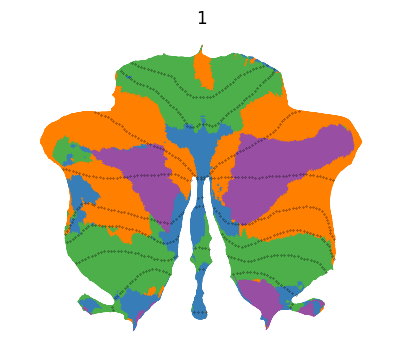

In [5]:
group = full_model.arrange.logpi
group_prob = pt.softmax(group,dim=0)
group_prob = group_prob.reshape(1,-1,group_prob.shape[-1])


group_vol = get_volumes(group_prob.cpu().numpy(),atlas_name='SUIT3')
flatmap.plot_multi_flat(group_vol,
                         grid=(6,5),colorbar= False,
                        cmap='Set1' ,dtype='prob',
                        space = 'SUIT',
                        render='matplotlib',
                        titles=np.arange(1,2),
                        bordersize = 0.5,
                        fig_size = (20,20))

In [6]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

# Load training and testing data

In [7]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


# Get Vs and G matrices

In [8]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb_1 = mdtb_1_Vs.cpu().numpy()
GL_mdtb_1 = VL_mdtb_1 @ VL_mdtb_1.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

# #make into np array
VL_mdtb_2 = mdtb_2_Vs.cpu().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

parcel1:Unsure -- parcel2:Motor -- parcel3:socio-linguistic -- parcel4:Multiple demand

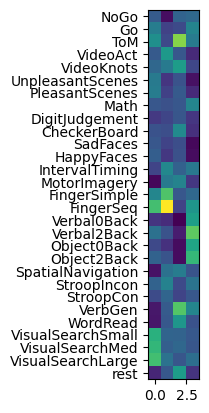

In [9]:
plt.imshow(VL_mdtb_1)
cond_names = info_mdtb_1_run['cond_name'][:len(VL_mdtb_1)] 
# add condition names from the info file
plt.yticks(np.arange(len(cond_names)), cond_names)
plt.show()

In [10]:
vtest = VL_mdtb_2

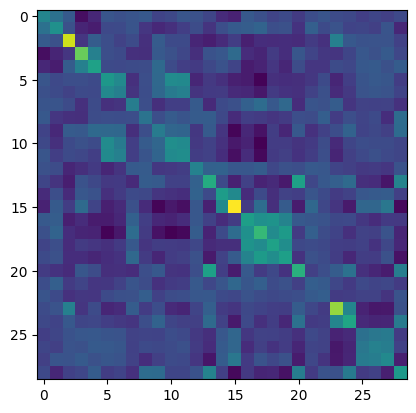

In [11]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

plt.imshow(G_individuals_averaged)

run evaluation on U_hats estimated using HBP framework - data only

In [31]:
D_mdtb = ut.build_combinations(G_individuals_averaged, strategy='balanced',n_iter=1000,n_tasks=8,seed=133,balanced_sampling_unique=[2,3,4,5,6,7,8])
D_mdtb = ev.evaluate_dataframe_real_multiregion(D_mdtb, data_mdtb_s1_all,VL_mdtb_1,data_mdtb_s2_all, vtest)

building0
Processing combination: 0


C:\Users\barafat\Documents\GitHub\OptimalBattery\evaluate.py:69: RuntimeWarning: invalid value encountered in divide
  ytest_normalized = ytest / ytest_norm_reshaped


Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900


In [43]:
D_mdtb['n_unique'].value_counts()
n_min = D_mdtb['n_unique'].value_counts().min()

(-0.02, 0.02)

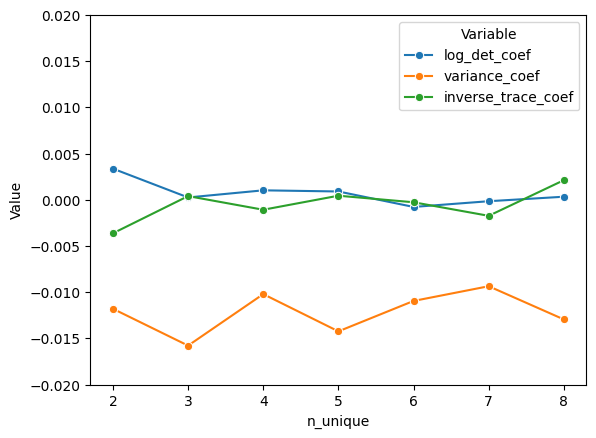

In [50]:
results_df = ut.run_regression_for_unique(df=D_mdtb,x_variables=['log_det','variance','inverse_trace'],y_variable='cos',n=n_min-1,random_state=3)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.ylim(-0.02,0.02)

(-0.02, 0.02)

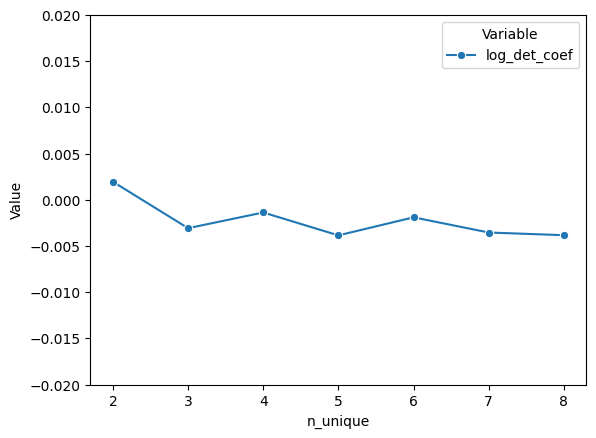

In [51]:
results_df = ut.run_regression_for_unique(df=D_mdtb,x_variables=['log_det'],y_variable='cos',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.ylim(-0.02,0.02)

(-0.02, 0.02)

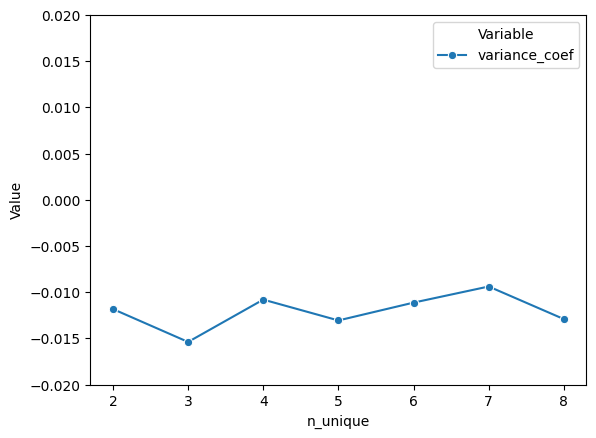

In [52]:
results_df = ut.run_regression_for_unique(df=D_mdtb,x_variables=['variance'],y_variable='cos',n=n_min-1,random_state=0)
df_melted = results_df.melt(
    id_vars=["n_unique"], 
    value_vars=[col for col in results_df.columns if col.endswith('_coef')],  
    var_name="Variable",
    value_name="Value"  
)
sns.lineplot(data=df_melted, x="n_unique", y="Value", hue="Variable", marker="o")
plt.ylim(-0.02,0.02)